# 00 — Fundamentos: rede neural, gradient descent e backpropagation

> Base pré-transformer, destilada dos capítulos 1–4 do 3Blue1Brown.
> Objetivo: ter na ponta da língua *o que* uma rede aprende e *como* — antes de
> montar o transformer (notebook 01 em diante).

Um transformer é, no fundo, **multiplicação de matrizes + não-linearidades**,
treinado por **descida de gradiente** com gradientes calculados por
**backpropagation**. Se esses três pilares estiverem sólidos, o resto é
arquitetura. Este notebook constrói os três à mão, com tensores pequenos que
rodam de verdade, e confere cada conta contra o `autograd` do PyTorch.

**O que você vai sair sabendo:**
1. O que é uma camada densa (o `nn.Linear` que aparece em todo lugar depois).
2. Por que existe uma função de custo e o que ela mede.
3. O que o gradiente diz e como o learning rate o usa.
4. Backprop como regra da cadeia aplicada de trás pra frente — conferido no autograd.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Convenção visual do projeto: figuras pequenas, grade suave, fontes legíveis.
plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__)

torch 2.12.1+cpu


Antes de tudo, as **funções de ativação** — a não-linearidade $\sigma$. Sem elas a
rede colapsa num único `Linear`. Repare no "joelho" da ReLU (zera o negativo) e na
saturação de sigmoide/tanh nas pontas (onde a derivada some — a origem do
*vanishing gradient* que reaparece no nb 03).

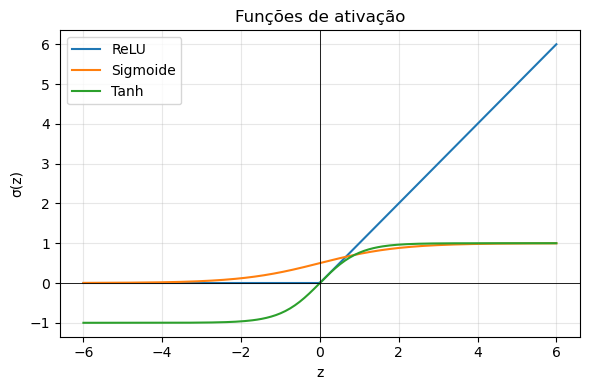

In [2]:
z = np.linspace(-6, 6, 200)
fig, ax = plt.subplots()
ax.plot(z, np.maximum(0, z), label="ReLU")
ax.plot(z, 1/(1+np.exp(-z)), label="Sigmoide")
ax.plot(z, np.tanh(z), label="Tanh")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("z"); ax.set_ylabel("σ(z)"); ax.set_title("Funções de ativação")
ax.legend(); plt.tight_layout(); plt.show()

## 1. O que é uma rede neural

Uma rede feed-forward é uma pilha de **camadas densas**. Cada camada faz uma
transformação afim seguida de uma não-linearidade:

$$ a^{(l)} = \sigma\big(W^{(l)} a^{(l-1)} + b^{(l)}\big) $$

- $W^{(l)}$ é a matriz de pesos (o que a rede aprende),
- $b^{(l)}$ o bias,
- $\sigma$ a ativação (ReLU, sigmoide, …) — sem ela, empilhar camadas colapsaria
  numa única transformação linear (composição de lineares é linear).

**Por que isso importa para o transformer:** o `W a + b` é exatamente o
`nn.Linear`. A MLP de cada bloco transformer é duas dessas camadas. A atenção
também é, no fim, projeções lineares (Q, K, V) com uma não-linearidade (softmax)
no meio. Dominar a camada densa é dominar 80% das peças.

In [3]:
# Uma camada densa "na mão", em numpy. Entrada de dimensão 3, saída de dimensão 2.
def relu(z):
    return np.maximum(0, z)

x = np.array([1.0, -2.0, 0.5])          # (3,)  um exemplo
W = np.array([[0.2, 0.8, -0.5],         # (2,3) pesos
              [-0.3, 0.1, 0.9]])
b = np.array([0.0, 0.1])                # (2,)

z = W @ x + b                           # pré-ativação (transformação afim)
a = relu(z)                             # ativação
print("z (pré-ativação):", z)
print("a (após ReLU)   :", a)
print("shapes:", "W", W.shape, "x", x.shape, "-> a", a.shape)

z (pré-ativação): [-1.65  0.05]
a (após ReLU)   : [0.   0.05]
shapes: W (2, 3) x (3,) -> a (2,)


A mesma camada em PyTorch. Repare que `nn.Linear(3, 2)` guarda um `W` de shape
`(2, 3)` e um `b` de shape `(2,)` — idênticos ao que fizemos à mão. É literalmente
o mesmo `W @ x + b`.

In [4]:
layer = nn.Linear(3, 2)
with torch.no_grad():                    # injeta os mesmos pesos p/ comparar
    layer.weight.copy_(torch.tensor(W, dtype=torch.float32))
    layer.bias.copy_(torch.tensor(b, dtype=torch.float32))

xt = torch.tensor(x, dtype=torch.float32)
at = F.relu(layer(xt))
print("PyTorch:", at.detach().numpy())
print("numpy  :", a)
print("batem? ", np.allclose(at.detach().numpy(), a, atol=1e-6))

PyTorch: [0.         0.04999999]
numpy  : [0.   0.05]
batem?  True


## 2. A função de custo: medir o quão errado a rede está

A rede começa com pesos aleatórios e erra. Precisamos de um número que meça o erro
— a **função de custo** (loss). Para regressão, o clássico é o erro quadrático médio:

$$ C = \frac{1}{N}\sum_{i=1}^{N}\big(\hat{y}_i - y_i\big)^2 $$

Treinar = achar os pesos que **minimizam** $C$. O custo é uma função dos pesos
(a entrada e o alvo são fixos); ajustamos $W, b$ para descê-la.

> No transformer o custo será **cross-entropy** (notebook 07), mas a mecânica é
> idêntica: um escalar diferenciável em função dos pesos, que minimizamos.

In [5]:
# Custo como função de UM peso, para visualizar a "paisagem" que minimizamos.
# Modelo trivial: y_hat = w * x. Alvo: y = 2*x (peso ótimo é w=2).
x_data = np.array([1.0, 2.0, 3.0, 4.0])
y_data = 2.0 * x_data

def cost(w):
    y_hat = w * x_data
    return np.mean((y_hat - y_data) ** 2)

ws = np.linspace(-1, 5, 25)
costs = [cost(w) for w in ws]
for w, c in zip(ws[::4], costs[::4]):
    bar = "#" * int(c)
    print(f"w={w:+.2f}  C={c:7.3f}  {bar}")
print("\nMínimo em w =", ws[int(np.argmin(costs))], "(esperado: 2.0)")

w=-1.00  C= 67.500  ###################################################################
w=+0.00  C= 30.000  ##############################
w=+1.00  C=  7.500  #######
w=+2.00  C=  0.000  
w=+3.00  C=  7.500  #######
w=+4.00  C= 30.000  ##############################
w=+5.00  C= 67.500  ###################################################################

Mínimo em w = 2.0 (esperado: 2.0)


## 3. Gradient descent: descer a paisagem de custo

O **gradiente** $\nabla C$ é o vetor das derivadas parciais de $C$ em relação a
cada peso. Ele aponta na direção de **maior subida** do custo. Logo, para
minimizar, andamos no sentido **oposto**:

$$ w \leftarrow w - \eta \, \frac{\partial C}{\partial w} $$

- $\eta$ é o **learning rate**: tamanho do passo. Pequeno demais → lento; grande
  demais → oscila ou diverge.
- Repetir isso muitas vezes é o treino.

Para o modelo $\hat{y} = w x$ com custo MSE, a derivada sai analítica:
$\frac{\partial C}{\partial w} = \frac{2}{N}\sum_i (w x_i - y_i)\, x_i$.

In [6]:
def grad(w):
    y_hat = w * x_data
    return np.mean(2 * (y_hat - y_data) * x_data)

w = 0.0            # chute inicial
eta = 0.05         # learning rate
for step in range(15):
    g = grad(w)
    w = w - eta * g
    if step % 3 == 0 or step == 14:
        print(f"step {step:2d}  w={w:.4f}  C={cost(w):.6f}  grad={g:+.4f}")
print("\nConvergiu para w ~", round(w, 3), "(ótimo: 2.0)")

step  0  w=1.5000  C=1.875000  grad=-30.0000
step  3  w=1.9922  C=0.000458  grad=-0.4688
step  6  w=1.9999  C=0.000000  grad=-0.0073
step  9  w=2.0000  C=0.000000  grad=-0.0001
step 12  w=2.0000  C=0.000000  grad=-0.0000
step 14  w=2.0000  C=0.000000  grad=-0.0000

Convergiu para w ~ 2.0 (ótimo: 2.0)


A figura abaixo torna isso concreto: a curva é a **paisagem de custo** $C(w)$ (uma
parábola, com mínimo em $w=2$); os pontos são a trajetória do gradient descent. Os
passos são **grandes longe do mínimo** (inclinação forte) e **encolhem perto do
fundo** — a "bolinha desacelerando no vale". É a imagem mental para o treino inteiro.

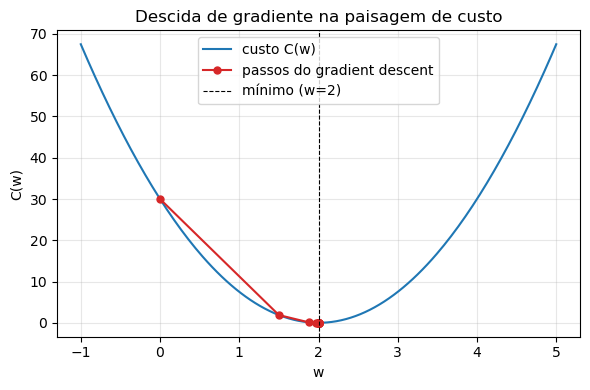

In [7]:
# Recomputa a trajetória guardando cada w para plotar sobre a paisagem de custo.
w_hist, w = [0.0], 0.0
for _ in range(15):
    w = w - 0.05 * grad(w)
    w_hist.append(w)
w_hist = np.array(w_hist)

grid = np.linspace(-1, 5, 200)
fig, ax = plt.subplots()
ax.plot(grid, [cost(w) for w in grid], color="C0", label="custo C(w)")
ax.plot(w_hist, [cost(w) for w in w_hist], "o-", color="C3", ms=5,
        label="passos do gradient descent")
ax.axvline(2.0, color="k", ls="--", lw=0.8, label="mínimo (w=2)")
ax.set_xlabel("w"); ax.set_ylabel("C(w)")
ax.set_title("Descida de gradiente na paisagem de custo")
ax.legend(); plt.tight_layout(); plt.show()

Observe o gradiente encolhendo à medida que nos aproximamos do mínimo: perto do
fundo do vale a inclinação é quase zero, então os passos ficam naturalmente
menores. É o mesmo mecanismo que roda no `06_treinamento.ipynb`, só que com
milhões de pesos e o gradiente vindo de backpropagation em vez de fórmula fechada.

### Experimente
Troque `eta` por `0.3` e depois `0.6`. Em algum ponto o treino **diverge** (o
custo explode). Ver isso na mão é a melhor intuição para *por que* o notebook 06
usa warmup + cosine decay + gradient clipping.

## 4. Backpropagation: gradiente em redes com várias camadas

No exemplo acima a derivada era fácil. Numa rede com várias camadas, o custo
depende dos pesos das primeiras camadas **através** de todas as seguintes.
Backpropagation é a **regra da cadeia** aplicada de trás para frente, reusando
resultados intermediários — é o que torna o cálculo do gradiente barato o
suficiente para escalar a bilhões de parâmetros.

Vamos derivar à mão o gradiente de uma rede minúscula de 2 camadas e conferir
contra o `autograd`. Rede: entrada escalar $x$ →
$h = \sigma(w_1 x + b_1)$ → $\hat{y} = w_2 h + b_2$ → custo $C = (\hat{y}-y)^2$,
com $\sigma$ = sigmoide.

Pela regra da cadeia, para $w_1$:

$$ \frac{\partial C}{\partial w_1}
 = \underbrace{\frac{\partial C}{\partial \hat y}}_{2(\hat y - y)}\cdot
   \underbrace{\frac{\partial \hat y}{\partial h}}_{w_2}\cdot
   \underbrace{\frac{\partial h}{\partial z_1}}_{\sigma'(z_1)}\cdot
   \underbrace{\frac{\partial z_1}{\partial w_1}}_{x} $$

Cada fator é local; backprop só multiplica esses fatores propagando o sinal
$\partial C/\partial(\cdot)$ da saída para a entrada.

In [8]:
# Valores concretos
x_, y_ = 1.5, 1.0
w1, b1, w2, b2 = 0.8, -0.2, 0.5, 0.1

def sigmoid(z): return 1 / (1 + np.exp(-z))

# ---- forward ----
z1 = w1 * x_ + b1
h  = sigmoid(z1)
y_hat = w2 * h + b2
C = (y_hat - y_) ** 2

# ---- backward (regra da cadeia, de trás pra frente) ----
dC_dyhat = 2 * (y_hat - y_)          # dC/dy_hat
dyhat_dh = w2                        # dy_hat/dh
dh_dz1   = h * (1 - h)               # sigmoide'
# gradientes de cada parâmetro
grad_w2 = dC_dyhat * h
grad_b2 = dC_dyhat * 1
grad_w1 = dC_dyhat * dyhat_dh * dh_dz1 * x_
grad_b1 = dC_dyhat * dyhat_dh * dh_dz1 * 1
print("à mão:  grad_w1=%.6f grad_b1=%.6f grad_w2=%.6f grad_b2=%.6f"
      % (grad_w1, grad_b1, grad_w2, grad_b2))

à mão:  grad_w1=-0.157625 grad_b1=-0.105083 grad_w2=-0.781459 grad_b2=-1.068941


In [9]:
# Confirmação pelo autograd do PyTorch: mesmas contas, feitas automaticamente.
tw1 = torch.tensor(w1, requires_grad=True)
tb1 = torch.tensor(b1, requires_grad=True)
tw2 = torch.tensor(w2, requires_grad=True)
tb2 = torch.tensor(b2, requires_grad=True)
tx = torch.tensor(x_); ty = torch.tensor(y_)

th = torch.sigmoid(tw1 * tx + tb1)
tyhat = tw2 * th + tb2
tC = (tyhat - ty) ** 2
tC.backward()                        # backprop: preenche .grad de cada folha
print("autograd: grad_w1=%.6f grad_b1=%.6f grad_w2=%.6f grad_b2=%.6f"
      % (tw1.grad, tb1.grad, tw2.grad, tb2.grad))
print("batem?", np.allclose(
    [grad_w1, grad_b1, grad_w2, grad_b2],
    [tw1.grad.item(), tb1.grad.item(), tw2.grad.item(), tb2.grad.item()], atol=1e-6))

autograd: grad_w1=-0.157625 grad_b1=-0.105083 grad_w2=-0.781459 grad_b2=-1.068941
batem? True


Os números batem: `loss.backward()` **é** a regra da cadeia que escrevemos à mão,
generalizada. Daqui pra frente confiamos no autograd — mas agora você sabe o que
ele calcula. Quando um gradiente "explodir" ou "sumir" no treino do transformer,
essa cadeia de multiplicações é onde a intuição mora (produtos de muitos fatores
< 1 desaparecem; > 1 explodem — é a motivação de normalização e init cuidadosa).

## 5. Juntando tudo: treinar uma MLP de verdade

Fechamos com o ciclo completo — forward → loss → backward → step — numa MLP
minúscula que aprende a função XOR (não linearmente separável, então *precisa* da
camada escondida). É o mesmo `for` do notebook 06, em escala de brinquedo.

In [10]:
# XOR: 4 exemplos, 2 features -> 1 saída
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
Y = torch.tensor([[0.],[1.],[1.],[0.]])

model = nn.Sequential(nn.Linear(2, 8), nn.Tanh(), nn.Linear(8, 1))
# Adam (lr=0.05): mais robusto que SGD puro nesta paisagem não-convexa —
# SGD com lr alto aqui diverge (vira nan). É o mesmo motivo de usarmos AdamW
# no treino do transformer (nb 06).
opt = torch.optim.Adam(model.parameters(), lr=0.05)

losses = []
for epoch in range(2000):
    opt.zero_grad()                  # zera gradientes do passo anterior
    pred = model(X)                  # forward
    loss = F.mse_loss(pred, Y)       # custo
    loss.backward()                  # backprop (preenche .grad)
    opt.step()                       # gradient descent (atualiza pesos)
    losses.append(loss.item())
    if epoch % 500 == 0:
        print(f"epoch {epoch:4d}  loss={loss.item():.4f}")

print("\nprevisões finais:", model(X).detach().squeeze().round().tolist(),
      " | alvo:", Y.squeeze().tolist())

epoch    0  loss=0.3288
epoch  500  loss=0.0000


epoch 1000  loss=0.0000
epoch 1500  loss=0.0000



previsões finais: [0.0, 1.0, 1.0, 0.0]  | alvo: [0.0, 1.0, 1.0, 0.0]


Duas figuras fecham o notebook. À **esquerda**, a curva de perda por epoch (eixo y
em log): o treino de qualquer rede é essa descida. À **direita**, a **fronteira de
decisão** aprendida — as cores mostram a saída do modelo em todo o plano. Repare que
ela é *curva*: uma reta jamais separaria o XOR (é o ponto de existir a camada
escondida com não-linearidade).

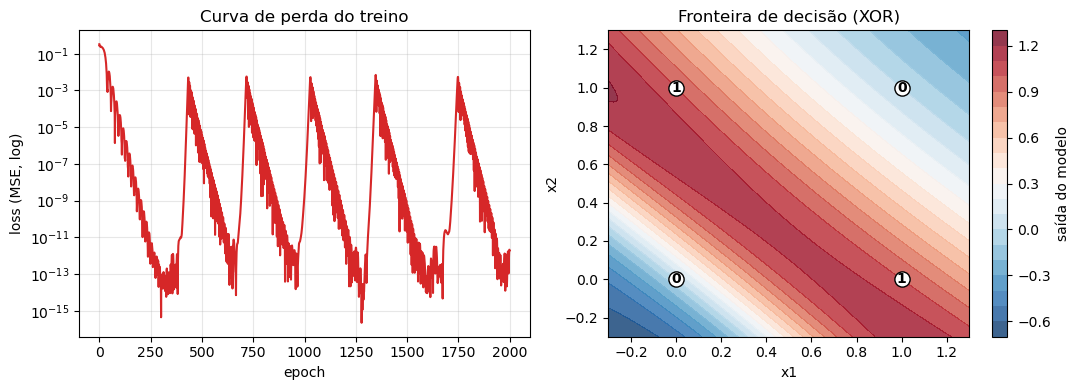

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# (a) curva de perda
ax1.plot(losses, color="C3"); ax1.set_yscale("log")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss (MSE, log)")
ax1.set_title("Curva de perda do treino")

# (b) fronteira de decisão: avalia o modelo numa grade 2D
gx, gy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
grid = torch.tensor(np.c_[gx.ravel(), gy.ravel()], dtype=torch.float32)
with torch.no_grad():
    zz = model(grid).reshape(gx.shape).numpy()
cf = ax2.contourf(gx, gy, zz, levels=20, cmap="RdBu_r", alpha=0.8)
for (px, py), t in zip(X.tolist(), Y.squeeze().tolist()):
    ax2.scatter(px, py, c="white", edgecolors="k", s=120)
    ax2.annotate(f"{int(t)}", (px, py), ha="center", va="center", fontweight="bold")
ax2.set_title("Fronteira de decisão (XOR)")
ax2.set_xlabel("x1"); ax2.set_ylabel("x2"); ax2.grid(False)
fig.colorbar(cf, ax=ax2, label="saída do modelo")
plt.tight_layout(); plt.show()

## Resumo (o que carregar para o notebook 01)

| Peça | O que é | Onde reaparece |
|---|---|---|
| Camada densa `W a + b` | transformação afim aprendida | `nn.Linear` em Q/K/V, MLP, lm_head |
| Não-linearidade | quebra a linearidade entre camadas | SiLU no SwiGLU (nb 04), softmax na atenção |
| Função de custo | escalar diferenciável a minimizar | cross-entropy (nb 07) |
| Gradiente / learning rate | direção e tamanho do passo | AdamW + scheduler (nb 06) |
| Backprop | regra da cadeia de trás pra frente | `loss.backward()` em todo treino |

**Caminho de evolução:** o próprio 3Blue1Brown (capítulos 1–4) para a intuição
visual; e, se quiser o formalismo de backprop em forma matricial, o cap. 6 do
livro *Deep Learning* (Goodfellow) na seção de computational graphs.

Próximo: **`01_transformer_intuicao.ipynb`** — atenção como média ponderada,
Q/K/V e máscara causal.